In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

# Venus' Altitudinal Composition Variation

The pressure and temperature variations in Venus' atmosphere are given in ```GGchem/structures/VenusHighResFit.dat```.

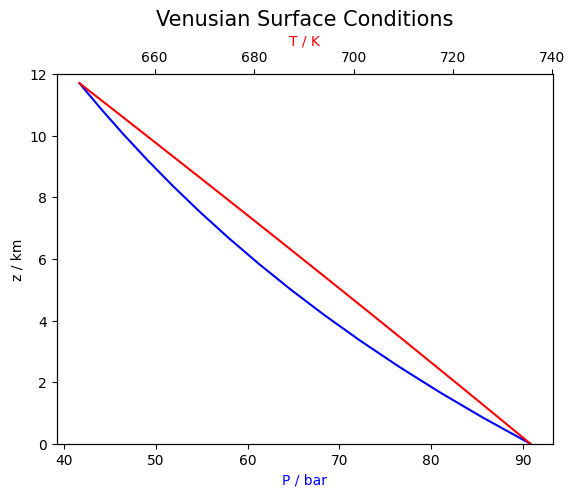

In [2]:
venus_structure = pd.read_csv('../GGchem/structures/VenusHighResFit.dat',
                              delim_whitespace=True,
                             index_col=0)[1:].set_index('z[km]')
max_alt_km = 12
venus_structure = venus_structure[venus_structure.index < max_alt_km]

fg, ax = plt.subplots()
ax2 = ax.twiny()

ax.plot(
    venus_structure['P[bar]'],
    venus_structure.index,
    c='b',
)
ax2.plot(
    venus_structure['T[K]'],
    venus_structure.index,
    c='r',
)

ax.set_xlabel('P / bar',
              color='b')
ax2.set_xlabel('T / K', color='r')
ax.set_ylabel('z / km')
ax.set_ylim([0,max_alt_km])
ax.set_title('Venusian Surface Conditions', fontsize=15);

The highest point on Venus' surface is Skadi Mons, at $12$km; the lowest is Diana Chasma, at $-2$km. The file goes from 0 to 250km, so we will make a new file to interpolate/extrapolate to Venus' surface conditions.

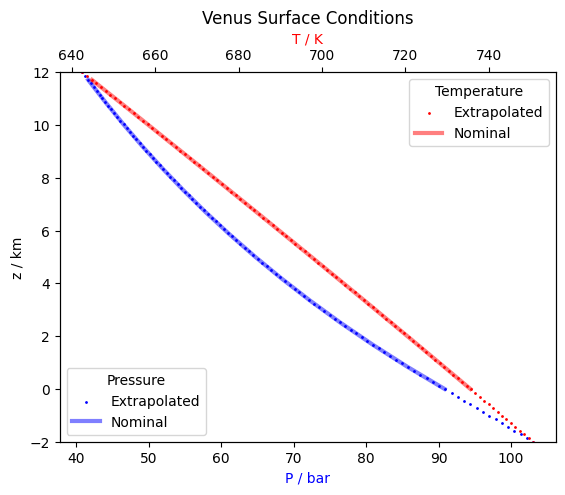

In [4]:
max_alt_km, npoints = 12, 100
# max_alt_km, npoints = 60, 1000 # Including regions with no surface
z_km = np.linspace(-2,max_alt_km,npoints)
T_K = interp1d(venus_structure.index, venus_structure['T[K]'], fill_value='extrapolate'
              )(z_km)
P_bar = interp1d(venus_structure.index, venus_structure['P[bar]'], fill_value='extrapolate'
                )(z_km)

fg, ax = plt.subplots()
ax2 = ax.twiny()
ax.scatter(P_bar, z_km, c='b', s=1, label='Extrapolated')
ax.plot(venus_structure['P[bar]'], venus_structure.index,
        c='b', alpha=.5, lw=3, label='Nominal')
ax2.scatter(T_K,z_km,
            c='r', s=1, label='Extrapolated')
ax2.plot(venus_structure['T[K]'], venus_structure.index,
         c='r', alpha=.5, lw=3, label='Nominal')
ax.set_xlabel('P / bar', color='b')
ax2.set_xlabel('T / K', color='r')
ax.set_ylabel('z / km');
ax.set_ylim([-2, max_alt_km])
ax.set_title('Venus Surface Conditions')

ax.legend(loc='lower left', title='Pressure')
ax2.legend(loc='upper right', title='Temperature');

We now create a file like ```VenusHighResFit.dat```, but with these inter-/extrapolated $p$-$T$ profiles, so that GGchem can run on those conditions.

In [4]:
with open('../GGchem/structures/VenusHighResFit.dat', 'r') as f:
    text = f.read()

extrapolated_profile_filetext = text.split('\n')[0] + '\n' # Headers
extrapolated_profile_filetext += f' {int(len(z_km))}\n' # Number of rows

for i, (z, P, T) in enumerate(zip(z_km, P_bar, T_K)):
    extrapolated_profile_filetext += (' '*(4-len(str(i)))) + f'{str(i)} {z:e} {P:e} {T:e} \n'

with open('../GGchem/structures/VenusSurfaceExtrapFit.dat','w') as f:
    f.write(extrapolated_profile_filetext)

This input file will be used to run GGchem (note you must be in the GGchem folder to run things properly!). The output is put into ```StaticConc.dat```, which I have moved to ```venus/surface_results.dat```. We now look at the results.

In [130]:
filename = f'./surface_results.dat'
# filename = f'./surface_results_high_alt.dat'
# Extracting numbers of elements, molecules and condensates
data = open(filename)
_  = data.readline()
dimensions = data.readline()
dimens = np.array(dimensions.split(), dtype=int)
N_elements = dimens[0]
N_molecules = dimens[1]
N_condensates = dimens[2]
# Reading into df
df = pd.read_csv(
    filename,
    delim_whitespace=True,
    skiprows=2,
)
df['z[km]'] = z_km
# df['z[km]'] = np.linspace(-2, 60, 849) # fsr GGchem didn't bother above ~50km
df.rename(columns = {'Tg':'T_K', 'pgas':'p_ubar'}, inplace=True)
df = df.set_index('z[km]')
df.tail()

,T_K,nHges,p_ubar,el,H,C,N,O,F,S,...,epsMg,epsCa,epsAl,epsNa,epsK,epsTi,dust/gas,dustVol/H,Jstar(W),Nstar(W)
z[km],,,,,,,,,,,,,,,,,,,,,
11.434343,647.0273,3.651147e+16,42406780.0,-300.0,0.578603,-35.398506,-15.947086,-10.751266,-8.593872,1.413194,...,-16.003079,-18.952450,-11.885547,-9.309338,-9.694193,-16.785116,3.345606,-15.163015,-300.0,999999.99999
11.575758,645.9052,3.623156e+16,42008680.0,-300.0,0.544619,-35.496416,-16.014967,-10.816490,-8.653701,1.368695,...,-16.029816,-18.980338,-11.926904,-9.328591,-9.714471,-16.831061,3.345606,-15.163015,-300.0,999999.99999
11.717172,644.7831,3.595068e+16,41610590.0,-300.0,0.510504,-35.594690,-16.083097,-10.881943,-8.713739,1.324040,...,-16.056634,-19.008325,-11.968383,-9.347899,-9.734806,-16.877142,3.345606,-15.163015,-300.0,999999.99999
11.858586,643.6610,3.566883e+16,41212500.0,-300.0,0.476258,-35.693331,-16.151477,-10.947625,-8.773989,1.279228,...,-16.083534,-19.036408,-12.009983,-9.367261,-9.755199,-16.923359,3.345607,-15.163015,-300.0,999999.99999
12.000000,642.5389,3.538598e+16,40814410.0,-300.0,0.441881,-35.792342,-16.220110,-11.013538,-8.834451,1.234258,...,-16.110517,-19.064590,-12.051705,-9.386676,-9.775650,-16.969712,3.345607,-15.163015,-300.0,999999.99999


In [24]:
gas_species_names = np.array(
    df.columns[3:4+N_elements+N_molecules]
)
gas_species_cm3 = np.array(df[gas_species_names]).reshape(
    (100, 1+N_elements+N_molecules)
)
gas_species_cm3 = gas_species_cm3.T # put species axis first. Shape: (349, 100)
gas_species_mr = 10**gas_species_cm3 / np.sum(10**gas_species_cm3, axis=0)

condensate_colnames = np.array(
    df.columns[4+N_elements+N_molecules+N_condensates:
               4+N_elements+N_molecules+2*N_condensates]
)
condensates_orig_units = np.array(df[condensate_colnames]).reshape(
    (100, N_condensates)
)
condensates_orig_units = condensates_orig_units.T # ", shape: (190,100)
condensates_mf = 10**condensates_orig_units / np.sum(10**condensates_orig_units, axis=0)

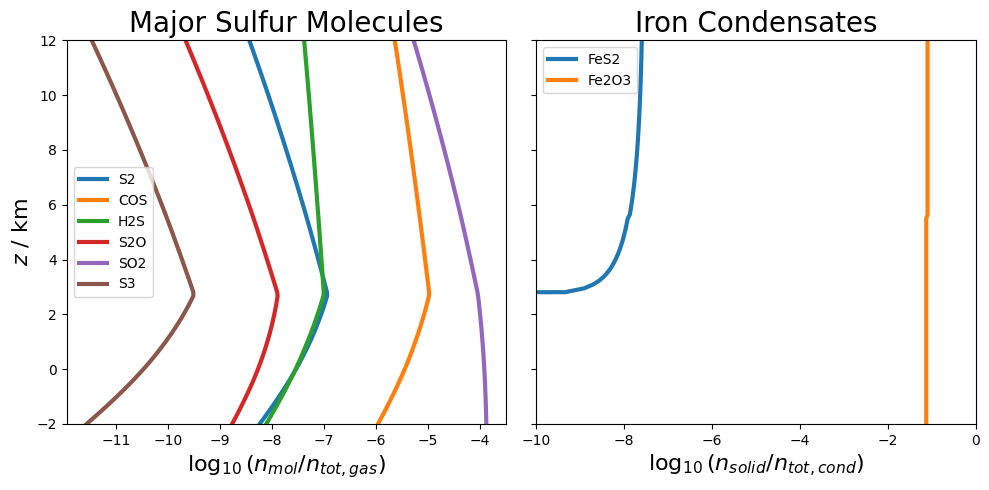

In [127]:
important_molecules = [
#     'CO2','N2',
#     'SO2','COS','H2S','S2',
#     'CO','H2O','H2','HCL','HF',#'Ar','Ne',
#     'H2SO4'
    gn for gn in gas_species_names\
    if ('S' in gn)&('SI' not in gn.upper())&\
    (np.max(gas_species_mr[gas_species_names==gn])>1e-10)
]
selected_condensates = [
    cn[1:] for cn in condensate_colnames\
#     if np.ptp(condensates_mf[condensate_colnames==cn]) > 1e-50
    if ('Fe' in cn)&\
    (np.max(condensates_mf[condensate_colnames==cn])>1e-300)
]

fg, axs = plt.subplots(1,2,figsize=(10,5),
                      sharey=True)
ax = axs[0]
for molecule in important_molecules:
    ax.plot(
        np.log10(
            gas_species_mr[gas_species_names==molecule][0]
        ),
        df.index,
        label=molecule,
        lw=3
)
ax.legend(important_molecules, fontsize=10)
ax.set_xlabel('$\log_{10} (n_{mol} / n_{tot, gas})$', fontsize=16)
ax.set_ylabel('$z$ / km', fontsize=16);
ax.set_ylim([
    np.min(df.index.tolist()),
    np.max(df.index.tolist())
])
ax.set_title('Major Sulfur Molecules', fontsize=20)

ax = axs[1]
for i, condensate in enumerate(selected_condensates):
    ax.plot(
        np.log10(
            condensates_mf[condensate_colnames==f'n{condensate}'][0]
        ),
        df.index,
        label=condensate,
        lw=3
    )
ax.legend(selected_condensates, fontsize=10)
ax.set_xlabel('$\log_{10} (n_{solid} / n_{tot, cond})$', fontsize=16)
ax.set_xlim([-10,0])
ax.set_ylim([
    np.min(df.index.tolist()),
    np.max(df.index.tolist())
])
ax.set_title('Iron Condensates', fontsize=20)
# ax.set_xscale('log');
plt.tight_layout()